# Generating Points on the Flag Manifold with Chordal-Matern Kernels

## Setup

In [1]:
import flagqmcpy 
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


## Kernel Setup

In [3]:
lam = torch.arange(1,4,device=DEVICE,dtype=float)
lam = lam/torch.linalg.norm(lam)
kernels = {nu: flagqmcpy.KernelMaternChordal(lam,nu) for nu in flagqmcpy.KernelMaternChordal.SUPPORTED_NU}
x_ref = flagqmcpy.genflag_x_eig_iid(2**0,lam,seed=7)
y_ref = flagqmcpy.genflag_x_eig_iid(2**22,lam,seed=11)
means = {nu: kernels[nu](x_ref[:,None,:,:],y_ref[None,:,:,:]).mean().item() for nu in flagqmcpy.KernelMaternChordal.SUPPORTED_NU}
means

{0.5: 0.6008151509534716,
 1.5: 0.7714766927278998,
 2.5: 0.813744990493801,
 3.5: 0.8312263080226889,
 4.5: 0.8404647970391437,
 5.5: 0.8461050916837007,
 6.5: 0.8498859649206227,
 inf: 0.8686474727394435}

## Transform and Generators

In [4]:
def opt_weights(x, eps=1e-12):
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat+eps*torch.eye(kmat.size(-1),device=DEVICE),upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w/w.sum(-1,keepdim=True)
def genflag_qr_iid_x_opt_w(n, lam, seed=None):
    x = flagqmcpy.genflag_x_qr_iid(n,lam,seed)
    w = opt_weights(x)
    return x,w
def genflag_qr_ld_x_opt_w(n, lam, seed=None):
    x = flagqmcpy.genflag_x_qr_ld(n,lam,seed)
    w = opt_weights(x)
    return x,w
def genflag_eig_iid_x_opt_w(n, lam, seed=None):
    x = flagqmcpy.genflag_x_eig_iid(n,lam,seed)
    w = opt_weights(x)
    return x,w
def genflag_eig_ld_x_opt_w(n, lam, seed=None):
    x = flagqmcpy.genflag_x_eig_ld(n,lam,seed)
    w = opt_weights(x)
    return x,w

## Optimized Points and Weights

In [27]:
def genflag_opt_x_w(
        n,
        lam,
        seed=None,
        verbose = False, 
        iters = 100,
        eps_kmat = 1e-8,
        verbose_indent = 4,
        ):
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    theta0 = flagqmcpy.tff_qr(u)
    zerosn = torch.zeros(n,device=DEVICE)
    onesn = torch.ones(n,device=DEVICE)
    eyen = torch.eye(n,device=DEVICE)
    def wce_recip_loss(theta):
        q = agsutil.to_unitary_qr(theta)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (n,n)
        L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
        v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
        return v,x,L
    u,x,L = agsutil.lm_opt(
        f = wce_recip_loss,
        theta0 = theta0,
        ytrue = zerosn,
        iters = iters,
        lam0 = 1e0,
        verbose = verbose,
        verbose_indent = verbose_indent,
        loss_mult = -1,
        # store_data_iters = True,
    )
    # print(data["losses_quantiles"]["50"])
    # print(data["losses_quantiles"]["50"][1:]-data["losses_quantiles"]["50"][:-1])
    w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
    w = w/w.sum(-1,keepdim=True)
    return x,w

kernel = kernels[1/2]
genflag_opt_x_w(
    n = 2**4, 
    lam=lam,
    seed = 17,
    verbose = None)
del kernel

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | -1.6e+00  | -1.6e+00  | -1.6e+00  | -1.6e+00  | -1.6e+00  | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.0        
    5          | -1.6e+00  | -1.6e+00  | -1.6e+00  | -1.6e+00  | -1.6e+00  | 3.1e-02   | 3.1e-02   | 3.1e-02   | 3.1e-02   | 3.1e-02   | 3.2e+01   | 3.2e+01   | 3.2e+0

## Convergence on a Test Function

In [16]:
def wce_plus_kappa(x, w):
    assert x.ndim>=2
    assert x.size(-3)==w.size(-1)
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    return torch.einsum("...i,...ij,...j->...",w,kmat,w) # (...,)

In [28]:
genf_funcs = [
    [r"QR IID $x$ ~ Equal $w$", flagqmcpy.genflag_x_qr_iid_equal_w], 
    [r"QR LD $x$ ~ Equal $w$", flagqmcpy.genflag_x_qr_ld_equal_w], 
    [r"QR IID $x$ ~ Opt $w$", genflag_qr_iid_x_opt_w], 
    [r"QR LD $x$ ~ Opt $w$", genflag_qr_ld_x_opt_w], 
    [r"Eig IID $x$ ~ Equal $w$", flagqmcpy.genflag_x_eig_iid_equal_w], 
    [r"Eig LD $x$ ~ Equal $w$", flagqmcpy.genflag_x_eig_ld_equal_w], 
    [r"Eig IID $x$ ~ Opt $w$", genflag_eig_iid_x_opt_w], 
    [r"Eig LD $x$ ~ Opt $w$", genflag_eig_ld_x_opt_w], 
    [r"Opt $x$ ~ Opt $w$", genflag_opt_x_w], 
    
]
nu = 1/2
kernel = kernels[nu]
n = 2**torch.arange(2,8)
trials = 5
seeds = [i for i in range(trials)]
wces = torch.empty((len(genf_funcs),len(n),trials))
t0 = time.perf_counter()
for i,(key,genf_func) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            x,w = genf_func(n=n[j],lam=lam,seed=seeds[t])
            wces[i,j,t] = float(wce_plus_kappa(x,w).cpu()-means[nu])
            print("        trial %-10d time %-10.1f discrep %-10.1e"%(t,time.perf_counter()-t0,wces[i,j,t]))

QR IID $x$ ~ Equal $w$
    n = 4
        trial 0          time 0.0        discrep 1.3e-01   
        trial 1          time 0.0        discrep 6.5e-02   
        trial 2          time 0.0        discrep 9.6e-02   
        trial 3          time 0.0        discrep 7.4e-02   
        trial 4          time 0.0        discrep 8.7e-02   
    n = 8
        trial 0          time 0.0        discrep 4.5e-02   
        trial 1          time 0.0        discrep 5.5e-02   
        trial 2          time 0.0        discrep 7.5e-02   
        trial 3          time 0.0        discrep 4.5e-02   
        trial 4          time 0.0        discrep 5.2e-02   
    n = 16
        trial 0          time 0.0        discrep 2.0e-02   
        trial 1          time 0.0        discrep 3.2e-02   
        trial 2          time 0.0        discrep 2.9e-02   
        trial 3          time 0.0        discrep 2.0e-02   
        trial 4          time 0.0        discrep 1.9e-02   
    n = 32
        trial 0          time 0.0  

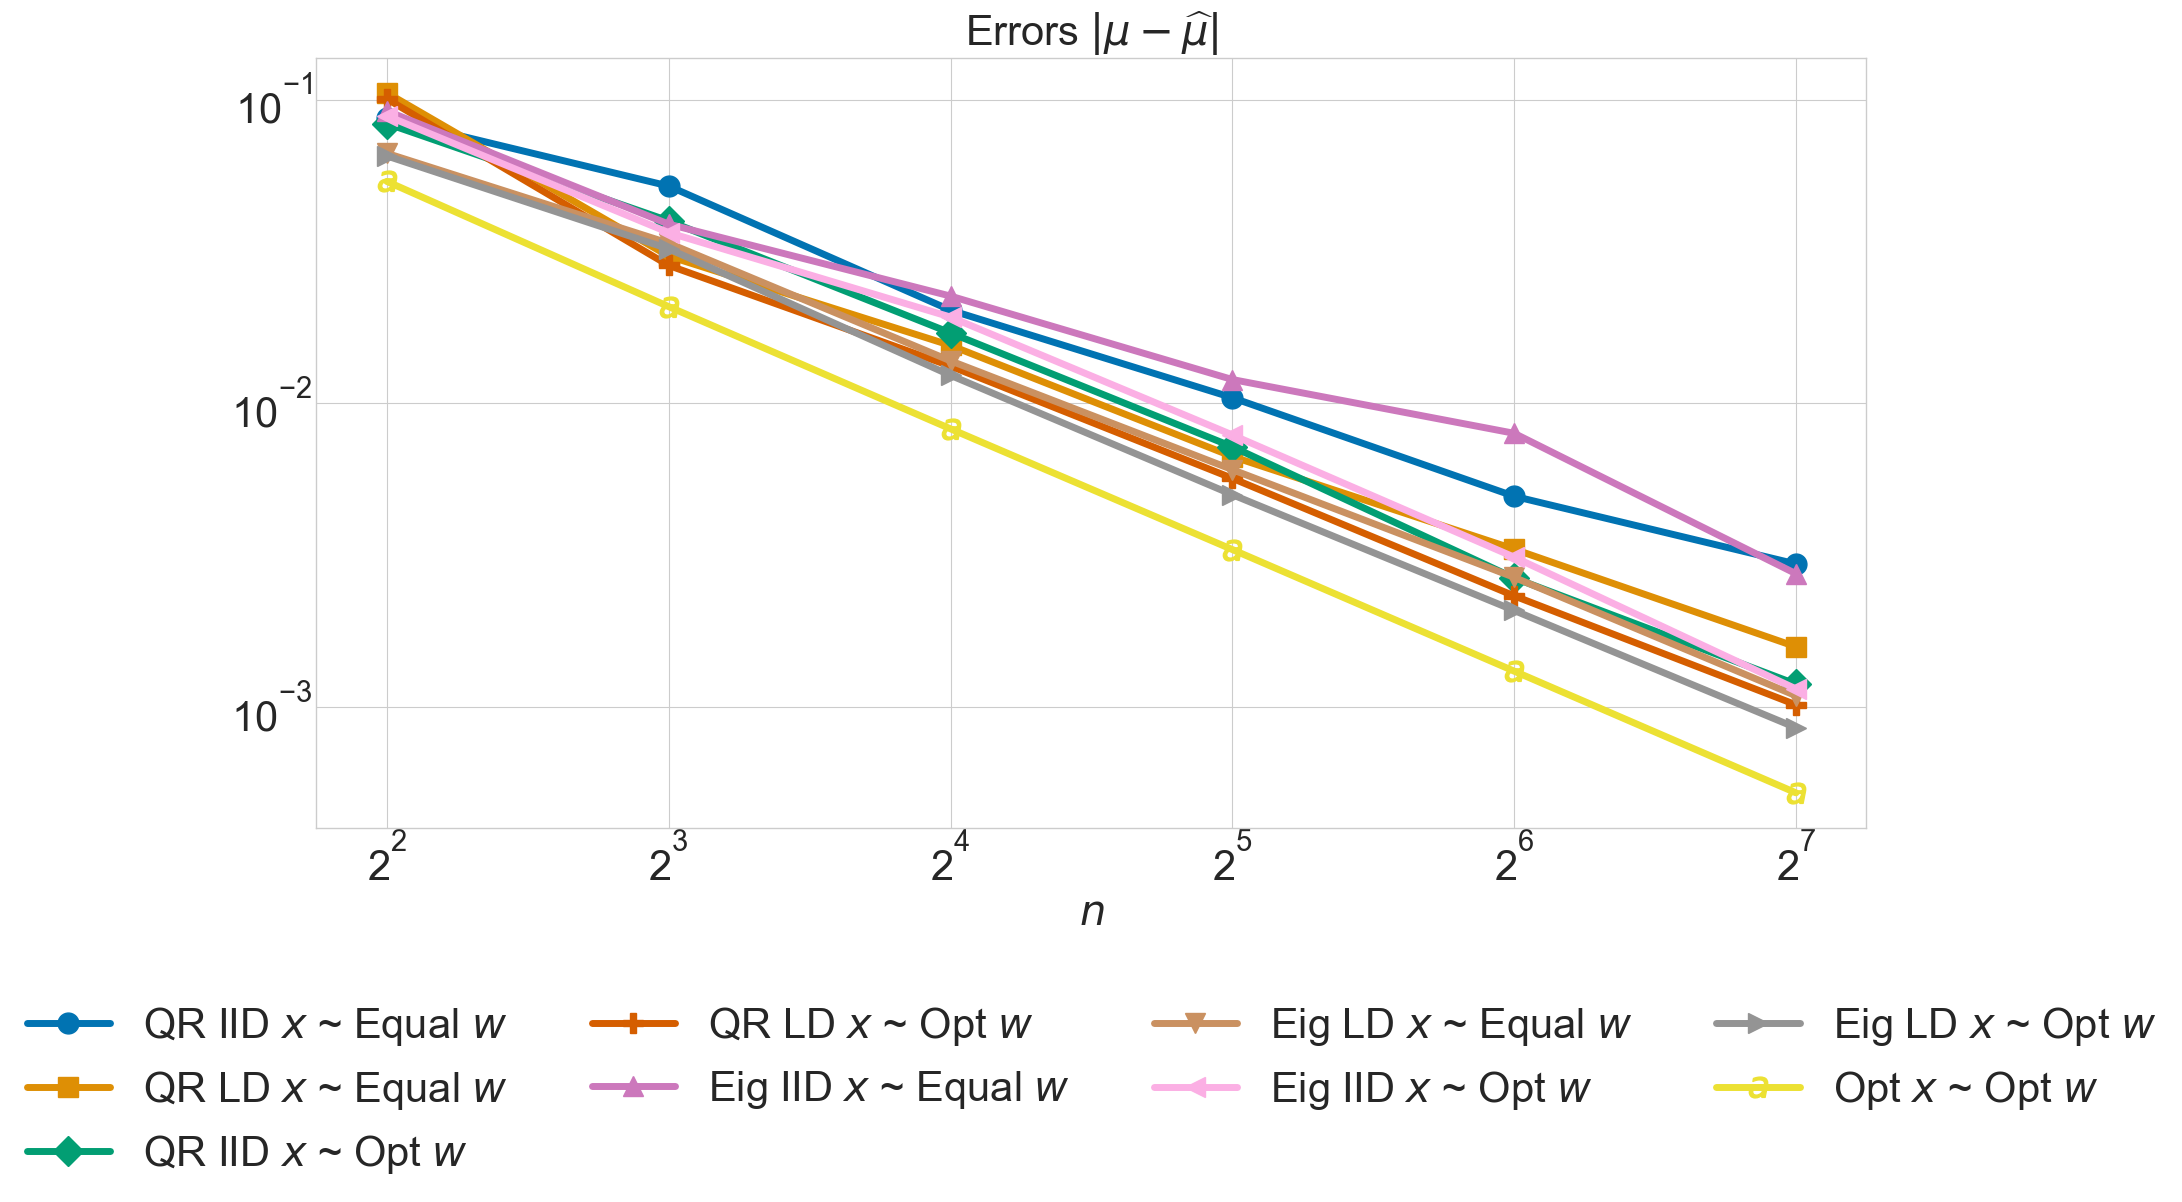

In [29]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/1.5,MPLP["PW"]/2/1.5),sharex=True,sharey=False)
for i,(key,_) in enumerate(genf_funcs):
    ax.plot(n,wces[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
# xmin,xmax = ax.get_xlim()
# ymin,ymax = ax.get_ylim()
# ax.set_xlim([xmin,xmax])
# ax.set_ylim([ymin,ymax])
# ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1/2})$",linestyle="dashed")
# ax.axline([xmin,ymax],[2*xmin,2**(-1)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1})$",linestyle="dotted")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.5))
ax.set_title(r"Errors $|\mu - \widehat{\mu}|$")
ax.set_xlabel(r"$n$");

In [ ]:
wces_df = pd.DataFrame(wces.median(-1).values.T,columns=[name for (name,_) in genf_funcs])
wces_df['n'] = n
wces_df.set_index('n')
print(r"WCEs")
wces_df.set_index('n')

WCEs


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$,Opt $x$ ~ Opt $w$
n,,,,,,,,,
4,0.086886,0.105256,0.083389,0.100526,0.091774,0.066536,0.088434,0.065221,0.053769
8,0.051911,0.030506,0.039860,0.028435,0.038893,0.033663,0.036474,0.032240,0.020808
16,0.020257,0.015507,0.017052,0.013252,0.022541,0.013796,0.019228,0.012361,0.008238
32,0.010431,0.006679,0.007192,0.005662,0.011973,0.006047,0.007868,0.005002,0.003299
64,0.004941,0.003309,0.002659,0.002322,0.007964,0.002672,0.003115,0.002078,0.001312
128,0.002958,0.001578,0.001189,0.001017,0.002746,0.001089,0.001147,0.000854,0.000522
